# CIFAR-10N Dataset Explorer

**Simple visual guide to understanding CIFAR-10N**

CIFAR-10N = CIFAR-10 + Human Noisy Labels

---

## 1. Setup: Load the Dataset

In [26]:
import sys
from pathlib import Path

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import matplotlib.pyplot as plt
from cifar10n_loader import CIFAR10NDataset

# CIFAR-10 class names
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

print("✓ Imports successful!")

✓ Imports successful!


In [27]:
# Load CIFAR-10N with 'worse_label' (highest noise)
dataset = CIFAR10NDataset(
    root='../../data/cifar10n',
    noise_type='worse_label',
    train=True,
    transform=None,  # No transform for visualization
    download=True
)

print(f"\n📊 Dataset Statistics:")
print(f"  Total samples: {len(dataset):,}")

# Check if noise data is available
if dataset.noise_mask is not None:
    print(f"  Noise rate: {dataset.noise_rate*100:.2f}%")
    print(f"  Noisy samples: {dataset.noise_mask.sum():,}")
    print(f"  Clean samples: {(~dataset.noise_mask).sum():,}")
else:
    print("\n⚠️  CIFAR-10N noise file not found!")
    print("\n📥 To use noisy labels, download CIFAR-10_human.pt from:")
    print("   https://github.com/UCSC-REAL/cifar-10-100n")
    print("\n📂 Place it in: data/cifar10/cifar-10-batches-py/CIFAR-10_human.pt")
    print("\n💡 For now, the notebook will use clean labels only.")

Loaded CIFAR-10N with worse_label: 40.21% noise

📊 Dataset Statistics:
  Total samples: 50,000
  Noise rate: 40.21%
  Noisy samples: 20,104
  Clean samples: 29,896


/Users/andrearachetta/Desktop/GigiApps/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## 2. What Does Each Sample Contain?

Each sample returns **4 values**:

In [28]:
# Get one random sample
import random
idx = random.randint(0, len(dataset) - 1)
image, noisy_label, clean_label, is_noisy = dataset[idx]

print(f"📍 Showing sample #{idx}\n")

print("🔍 Sample Breakdown:\n")
print(f"1. image:        {type(image).__name__} with shape {image.size}")
print(f"2. noisy_label:  {noisy_label} ({CLASS_NAMES[noisy_label]})")
print(f"3. clean_label:  {clean_label} ({CLASS_NAMES[clean_label]})")
print(f"4. is_noisy:     {is_noisy}")

if is_noisy:
    print(f"\n⚠️  MISLABELED! Human said '{CLASS_NAMES[noisy_label]}' but it's actually '{CLASS_NAMES[clean_label]}'")
else:
    print(f"\n✓ CORRECT! Human correctly labeled as '{CLASS_NAMES[clean_label]}'")

📍 Showing sample #7332

🔍 Sample Breakdown:

1. image:        Image with shape (32, 32)
2. noisy_label:  2 (bird)
3. clean_label:  2 (bird)
4. is_noisy:     False

✓ CORRECT! Human correctly labeled as 'bird'


## 3. Visualize: Clean vs Noisy Samples

Let's see examples of correctly labeled and mislabeled images:

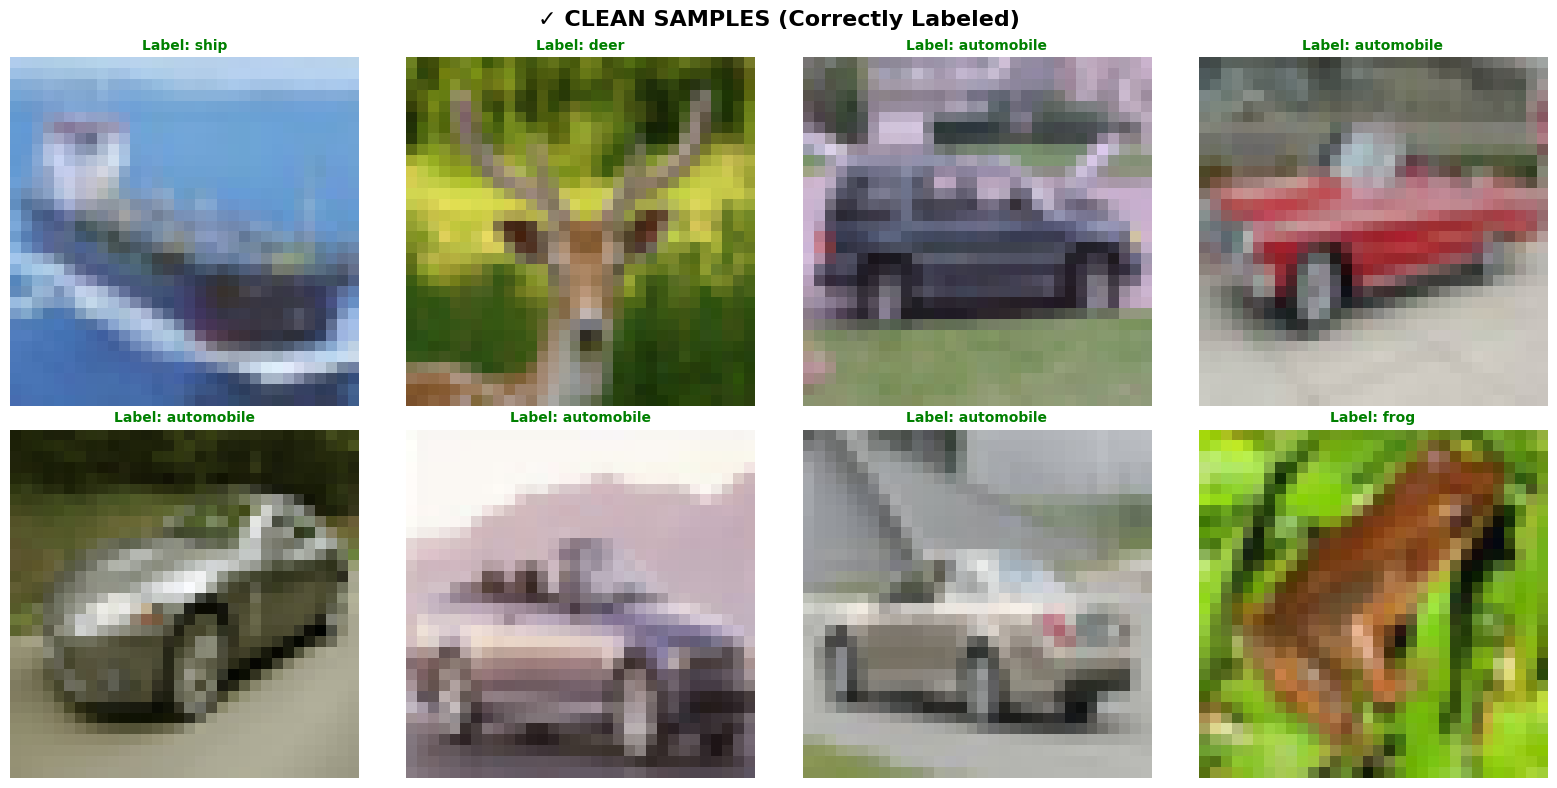

In [29]:
def show_samples(dataset, is_noisy_filter, n_samples=8, title="Samples"):
    """Show sample images with labels."""
    # Check if noise data is available
    if dataset.noise_mask is None:
        print("⚠️  Cannot show noisy/clean samples - CIFAR-10N noise file not loaded.")
        print("Please download CIFAR-10_human.pt first (see cell above).")
        return
    
    # Find indices matching filter
    indices = np.where(dataset.noise_mask == is_noisy_filter)[0]
    
    if len(indices) == 0:
        print(f"⚠️  No samples found with is_noisy={is_noisy_filter}")
        return
    
    selected = np.random.choice(indices, size=min(n_samples, len(indices)), replace=False)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    for idx, ax in zip(selected, axes.flat):
        image, noisy_label, clean_label, is_noisy = dataset[idx]
        
        # Display image
        ax.imshow(image)
        ax.axis('off')
        
        # Create label text
        if is_noisy:
            label_text = f"Human: {CLASS_NAMES[noisy_label]}\nTruth: {CLASS_NAMES[clean_label]}"
            color = 'red'
        else:
            label_text = f"Label: {CLASS_NAMES[clean_label]}"
            color = 'green'
        
        ax.set_title(label_text, fontsize=10, color=color, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Show clean samples
show_samples(dataset, is_noisy_filter=False, title="✓ CLEAN SAMPLES (Correctly Labeled)")

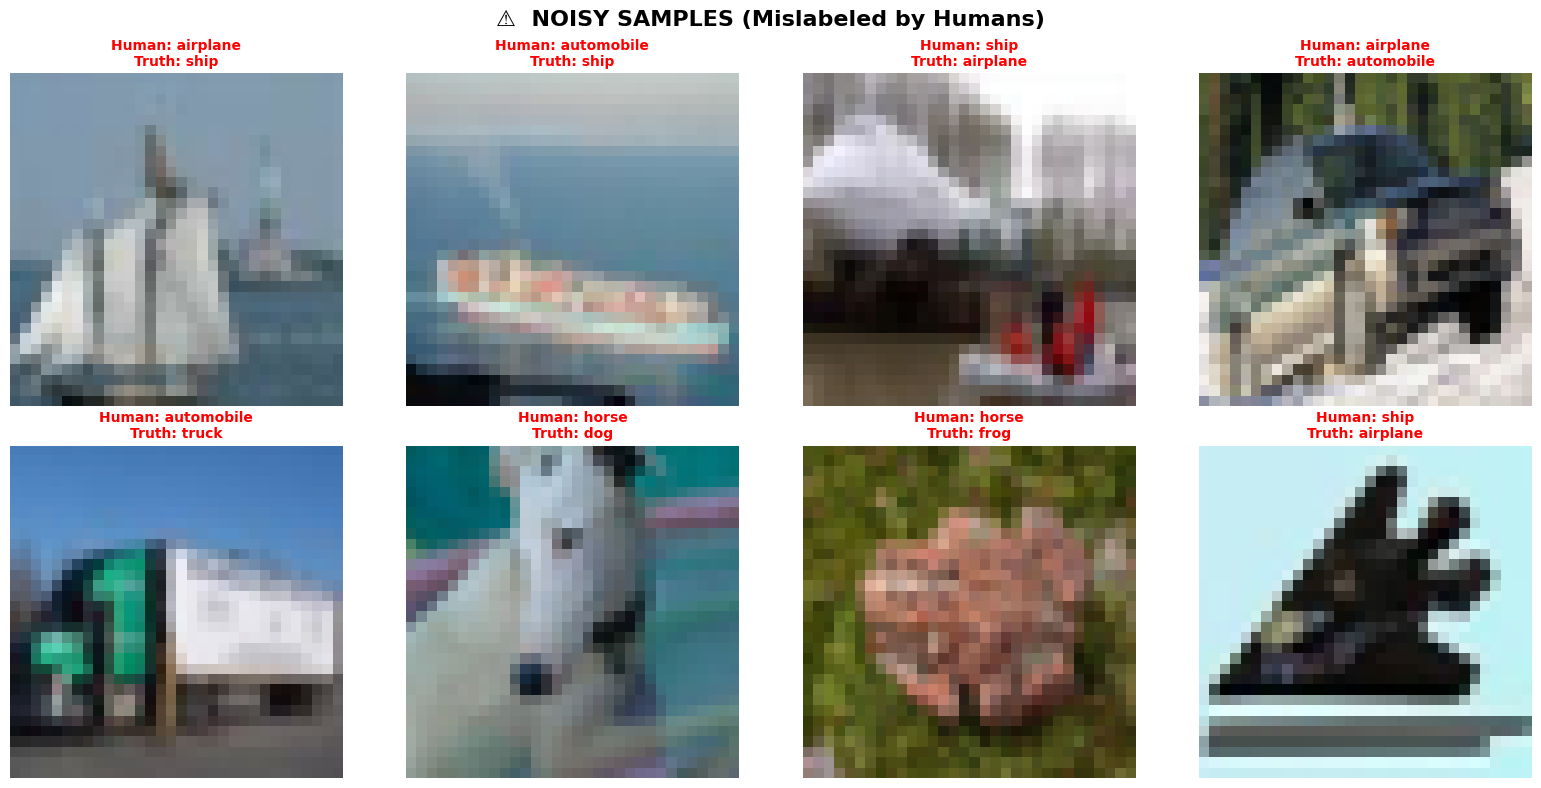

In [34]:
# Show noisy samples
show_samples(dataset, is_noisy_filter=True, title="⚠️  NOISY SAMPLES (Mislabeled by Humans)")

## 4. Noise Distribution: Which Classes Are Most Confused?

Let's see which classes humans mislabel most often:

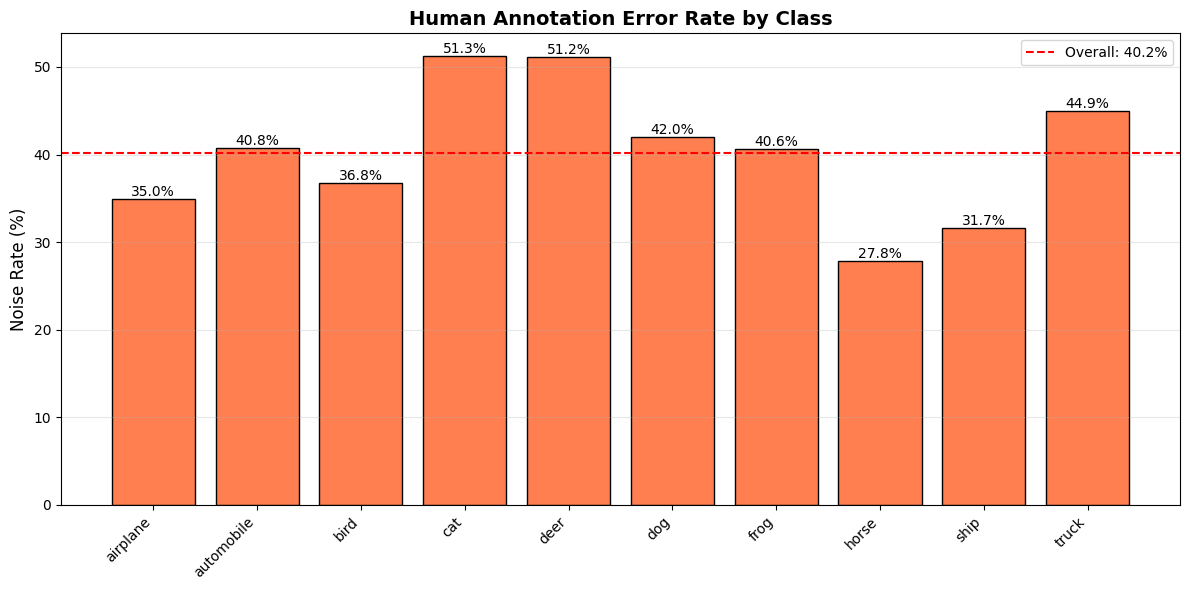


🎯 Key Insights:
  Most confused: cat (51.3% error)
  Least confused: horse (27.8% error)


In [31]:
# Check if noise data is available
if dataset.noise_mask is None:
    print("⚠️  Cannot show noise distribution - CIFAR-10N noise file not loaded.")
    print("Please download CIFAR-10_human.pt first.")
else:
    # Calculate noise rate per class
    noise_per_class = []
    for cls in range(10):
        cls_mask = np.array(dataset.cifar10.targets) == cls
        cls_noise_rate = dataset.noise_mask[cls_mask].mean()
        noise_per_class.append(cls_noise_rate * 100)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(CLASS_NAMES, noise_per_class, color='coral', edgecolor='black')
ax.set_ylabel('Noise Rate (%)', fontsize=12)
ax.set_title('Human Annotation Error Rate by Class', fontsize=14, fontweight='bold')
ax.axhline(y=dataset.noise_rate*100, color='red', linestyle='--', label=f'Overall: {dataset.noise_rate*100:.1f}%')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, noise_per_class):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n🎯 Key Insights:")
most_confused = CLASS_NAMES[np.argmax(noise_per_class)]
least_confused = CLASS_NAMES[np.argmin(noise_per_class)]
print(f"  Most confused: {most_confused} ({max(noise_per_class):.1f}% error)")
print(f"  Least confused: {least_confused} ({min(noise_per_class):.1f}% error)")

## 5. Confusion Matrix: What Do Humans Confuse?

When humans make mistakes, what do they confuse?

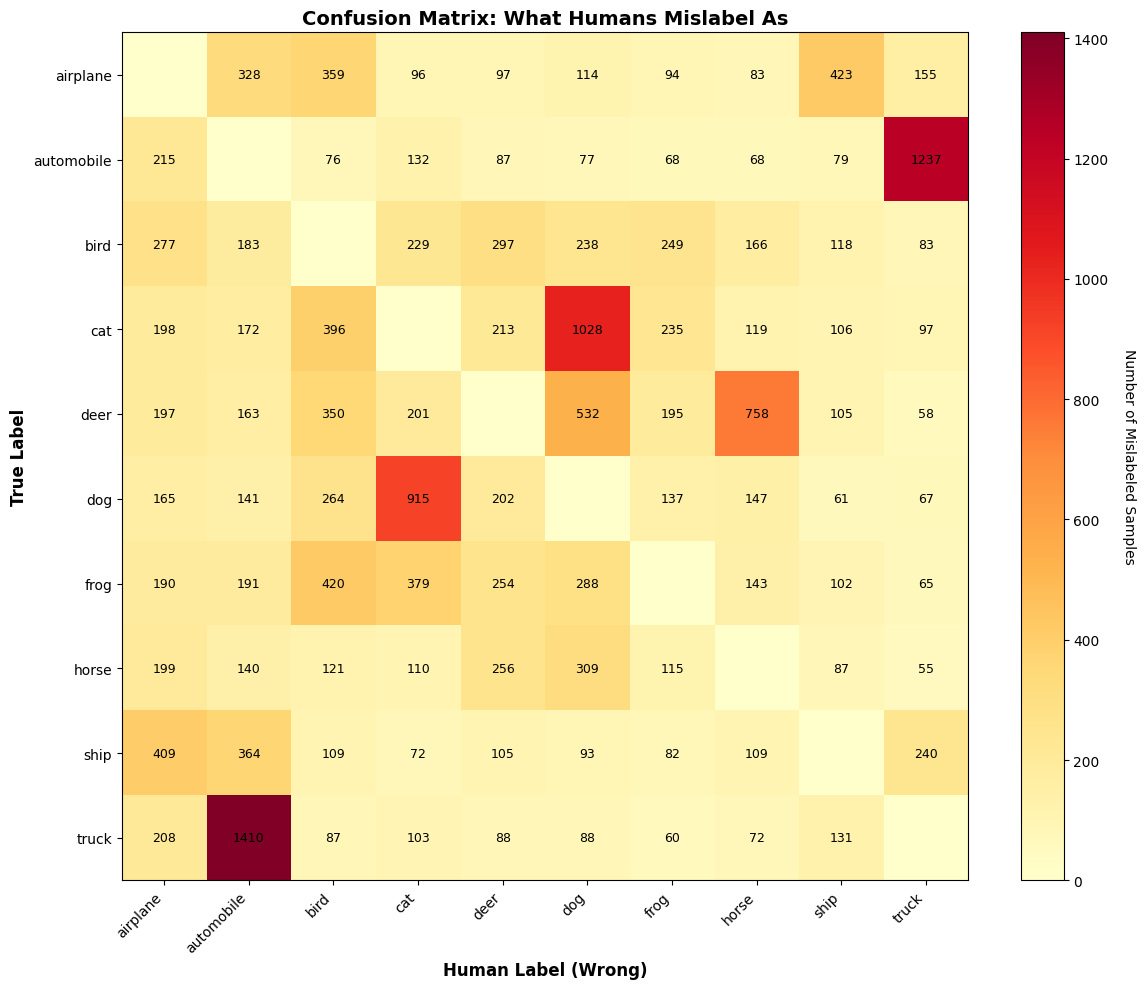


🔀 Top 5 Most Common Confusions:
  1.      truck → automobile: 1410 times
  2. automobile →      truck: 1237 times
  3.        cat →        dog: 1028 times
  4.        dog →        cat:  915 times
  5.       deer →      horse:  758 times


In [32]:
# Check if noise data is available
if dataset.noise_mask is None:
    print("⚠️  Cannot show confusion matrix - CIFAR-10N noise file not loaded.")
    print("Please download CIFAR-10_human.pt first.")
else:
    # Build confusion matrix (only for noisy samples)
    confusion = np.zeros((10, 10), dtype=int)
    
    for idx in range(len(dataset)):
        _, noisy_label, clean_label, is_noisy = dataset[idx]
        if is_noisy:
            confusion[clean_label, noisy_label] += 1

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(confusion, cmap='YlOrRd', aspect='auto')

# Labels
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Human Label (Wrong)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix: What Humans Mislabel As', fontsize=14, fontweight='bold')

# Add text annotations
for i in range(10):
    for j in range(10):
        if confusion[i, j] > 0:
            text = ax.text(j, i, confusion[i, j],
                          ha="center", va="center", color="black", fontsize=9)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Number of Mislabeled Samples', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

# Find most common confusions
print("\n🔀 Top 5 Most Common Confusions:")
flat_idx = np.argsort(confusion.flatten())[::-1]
for rank, idx in enumerate(flat_idx[:5], 1):
    true_cls = idx // 10
    wrong_cls = idx % 10
    count = confusion[true_cls, wrong_cls]
    if count > 0:
        print(f"  {rank}. {CLASS_NAMES[true_cls]:>10} → {CLASS_NAMES[wrong_cls]:>10}: {count:>4} times")

## 6. Why This Matters for Uncertainty Research

**Key Takeaways:**

1. **Real-World Noise:** Human annotators make mistakes (~40% in `worse_label`)
2. **Aleatoric Uncertainty:** Noisy labels create inherent ambiguity
3. **Class Imbalance:** Some classes are harder to label (e.g., cat vs dog)
4. **Training Challenge:** Models must learn despite label errors

**How We Use This:**
- Train on `noisy_labels` (realistic scenario)
- Evaluate on `clean_labels` (true performance)
- Detect which samples are mislabeled (uncertainty classification)
- Distinguish aleatoric (noisy) from epistemic (under-supported) uncertainty

## 7. Quick Stats Summary

In [33]:
print("="*60)
print("CIFAR-10N DATASET SUMMARY")
print("="*60)
print(f"\n📦 Dataset: {dataset.noise_type}")
print(f"   Total samples: {len(dataset):,}")

if dataset.noise_mask is not None:
    print(f"   Clean samples: {(~dataset.noise_mask).sum():,} ({(~dataset.noise_mask).mean()*100:.1f}%)")
    print(f"   Noisy samples: {dataset.noise_mask.sum():,} ({dataset.noise_mask.mean()*100:.1f}%)")
    print(f"\n🎯 Classes: {len(CLASS_NAMES)}")
    print(f"   {', '.join(CLASS_NAMES)}")
    print(f"\n⚠️  Noise Characteristics:")
    print(f"   Overall noise rate: {dataset.noise_rate*100:.2f}%")
    if 'noise_per_class' in locals():
        print(f"   Most confused class: {CLASS_NAMES[np.argmax(noise_per_class)]} ({max(noise_per_class):.1f}%)")
        print(f"   Least confused class: {CLASS_NAMES[np.argmin(noise_per_class)]} ({min(noise_per_class):.1f}%)")
else:
    print(f"\n🎯 Classes: {len(CLASS_NAMES)}")
    print(f"   {', '.join(CLASS_NAMES)}")
    print(f"\n⚠️  Noise data not available (using clean labels only)")

print("\n" + "="*60)

CIFAR-10N DATASET SUMMARY

📦 Dataset: worse_label
   Total samples: 50,000
   Clean samples: 29,896 (59.8%)
   Noisy samples: 20,104 (40.2%)

🎯 Classes: 10
   airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

⚠️  Noise Characteristics:
   Overall noise rate: 40.21%
   Most confused class: cat (51.3%)
   Least confused class: horse (27.8%)



---

## Next Steps

Now that you understand the data, you can:

1. **Train models** on noisy labels (realistic)
2. **Evaluate** on clean labels (true performance)
3. **Detect noise** using uncertainty methods
4. **Compare** different noise types (`worse_label`, `aggre_label`, etc.)

See `cifar10n_loader.py` for the full API!